# C03 · Bike sharing: demand forecasts that admit what they do not know

| | |
|---|---|
| **Difficulty** | ★★★☆☆ |
| **Time** | 3-4 hours |
| **Data** | Capital Bikeshare (Washington DC) daily rental counts 2011-2012 with weather and calendar covariates |
| **Skills** | Count likelihoods and the log link · diagnosing a predictive distribution that is far too confident · non-linear effects with splines · index variables and `ZeroSumNormal` · LOO model comparison · pointwise LOO and Pareto-$k$ as an anomaly detector · out-of-sample forecasting with `pm.Data` · interval coverage · turning a predictive distribution into a capacity decision |

## The brief

The operations team of a bike-sharing scheme plans two things a day ahead: how many vans
and staff to put on **rebalancing** (moving bikes from full docks to empty ones), and how
many bikes to have in service. Both scale with the number of rentals they must be able to
serve tomorrow. Plan too low and customers find empty docks; plan too high and vans and
people stand idle.

They have a weather forecast for tomorrow and two years of history. What they ask for:

> "Give us tomorrow's demand **with a range we can trust**. If you say 90%, we want to be
> inside it nine days out of ten. And tell us how much capacity to plan so that we can
> cover demand on **95% of days**."

From conversations with the team you know that a typical day sees a few thousand rentals,
that a busy summer day can reach eight thousand, and that the system is growing fast.

A point forecast is the easy half of this. The brief is about the *spread*: a predictive
distribution whose stated probabilities can be taken at face value. Sampler diagnostics
will not tell you whether you have one.

## How this notebook works

- Each task states **what to deliver**, not how. Write your code in the `YOUR CODE HERE` cells.
- Stuck? `h.hint("task2")` reveals hints one level at a time: *nudge → approach → code skeleton*.
  Try to get by on nudges.
- `h.check("task2", coverage90=...)` compares your numbers with the reference solution.
- A full worked solution lives in `notebooks/solutions/`. Open it only when you are done (or truly stuck).

In [1]:
import arviz as az
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import pymc as pm

from pymc_challenges import Hints, data

RANDOM_SEED = 2012
rng = np.random.default_rng(RANDOM_SEED)
az.style.use("arviz-variat")

h = Hints("C03")
h.tasks()

**C03 - Bike sharing: demand forecasts that admit what they do not know**

- `task0` - Decode, split, look (2 hints, 2 check(s))
- `task1` - The textbook model for counts (3 hints, 1 check(s))
- `task2` - Fix what Task 1 revealed (3 hints, 3 check(s))
- `task3` - Too hot to cycle (3 hints, 2 check(s))
- `task4` - Calendar, weather situation, growth - and a scoreboard (3 hints, 2 check(s))
- `task5` - The days the model cannot believe (3 hints, 2 check(s))
- `task6` - Open the hold-out (3 hints, 3 check(s))
- `task7` - How much capacity? (3 hints, 3 check(s))

## The data

One row per day, 1 January 2011 to 31 December 2012. `cnt` is the total number of rentals
(`casual` + `registered`). Calendar columns: `yr` (0 = 2011, 1 = 2012), `mnth`, `weekday`
(an integer - find out which day is 0), `holiday`, `workingday` (neither weekend nor
holiday). `weathersit` is the day's weather situation: 1 = clear or partly cloudy,
2 = mist or overcast, 3 = light rain or snow, thunderstorm.

The UCI file stores the continuous weather variables **normalised** - each was divided by
a constant so that it lies between 0 and 1:

| column | meaning | divided by |
|---|---|---|
| `temp` | mean temperature, °C | 41 |
| `atemp` | "feels-like" temperature, °C | 50 |
| `hum` | relative humidity, % | 100 |
| `windspeed` | wind speed, km/h | 67 |

Nobody on the operations team thinks in units of "0.34 of 41 °C".

In [2]:
data.describe("bike_day")
raw = data.load("bike_day")
raw.head()

bike_day: Daily rental counts 2011-2012 with weather and calendar covariates.
  source: Fanaee-T & Gama (2013), Capital Bikeshare (Washington DC), UCI ML Repository.
  url:    https://archive.ics.uci.edu/static/public/275/bike+sharing+dataset.zip


,instant,dteday,season,yr,mnth,holiday,weekday,workingday,weathersit,temp,atemp,hum,windspeed,casual,registered,cnt
0,1,2011-01-01,1,0,1,0,6,0,2,0.344167,0.363625,0.805833,0.160446,331,654,985
1,2,2011-01-02,1,0,1,0,0,0,2,0.363478,0.353739,0.696087,0.248539,131,670,801
2,3,2011-01-03,1,0,1,0,1,1,1,0.196364,0.189405,0.437273,0.248309,120,1229,1349
3,4,2011-01-04,1,0,1,0,2,1,1,0.200000,0.212122,0.590435,0.160296,108,1454,1562
4,5,2011-01-05,1,0,1,0,3,1,1,0.226957,0.229270,0.436957,0.186900,82,1518,1600


The **final eight weeks** (56 days, from 6 November 2012) are the hold-out. They stay locked
away until Task 6: no plots, no fitting, no peeking.

In [3]:
HOLDOUT_START = pd.Timestamp("2012-11-06")

## Task 0 · Decode, split, look

**Deliver**
1. A data frame with the weather in physical units (°C, %, km/h) and readable labels for
   weekday and weather situation. Verify the weekday coding rather than guessing it.
2. `train` (before `HOLDOUT_START`) and `test` (the rest).
3. Plots of the training data that show what a demand model will have to reproduce: the
   series over time, demand against temperature, demand by weather situation and by weekday.
   Write down the three or four features you consider essential. Do you need both `temp`
   and `atemp`?

In [4]:
WEEKDAYS = ["Sun", "Mon", "Tue", "Wed", "Thu", "Fri", "Sat"]
WEATHER = ["clear", "mist", "wet"]

# which day is weekday 0? ask the dates instead of guessing
print(pd.crosstab(raw.dteday.dt.day_name(), raw.weekday).idxmax().to_dict())


def prepare(df):
    return df.assign(
        temp_c=df.temp * 41,
        hum_pct=df.hum * 100,
        wind_kmh=df.windspeed * 67,
        t=(df.dteday - pd.Timestamp("2011-01-01")).dt.days / 365.25,  # time in years
        weekday_name=pd.Categorical.from_codes(df.weekday, WEEKDAYS),
        weather=pd.Categorical.from_codes(df.weathersit - 1, WEATHER),
    )


bikes = prepare(raw)
train = bikes[bikes.dteday < HOLDOUT_START].copy()
test = bikes[bikes.dteday >= HOLDOUT_START].copy()
print(f"train: {len(train)} days, test: {len(test)} days")
print(f"correlation of temp and atemp: {bikes.temp_c.corr(bikes.atemp):.3f}")
bikes[["temp_c", "hum_pct", "wind_kmh", "cnt"]].describe().round(1)

{0: 'Sunday', 1: 'Monday', 2: 'Tuesday', 3: 'Wednesday', 4: 'Thursday', 5: 'Friday', 6: 'Saturday'}
train: 675 days, test: 56 days
correlation of temp and atemp: 0.992


,temp_c,hum_pct,wind_kmh,cnt
count,731.0,731.0,731.0,731.0
mean,20.3,62.8,12.8,4504.3
std,7.5,14.2,5.2,1937.2
min,2.4,0.0,1.5,22.0
25%,13.8,52.0,9.0,3152.0
50%,20.4,62.7,12.1,4548.0
75%,26.9,73.0,15.6,5956.0
max,35.3,97.2,34.0,8714.0


In [5]:
assert h.check("task0", mean_temp_c=bikes.temp_c.mean(), max_wind_kmh=bikes.wind_kmh.max())

- PASS `mean_temp_c` = 20.31 is consistent with the reference solution.
- PASS `max_wind_kmh` = 34 is consistent with the reference solution.

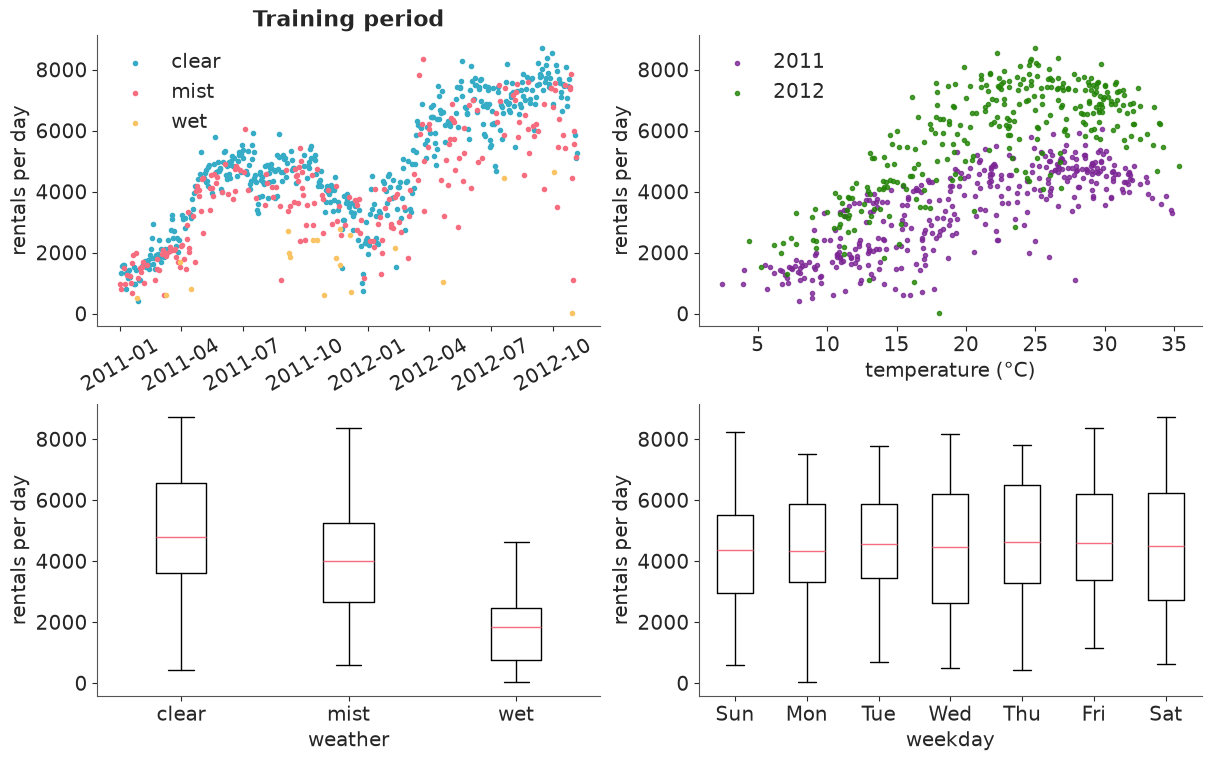

In [6]:
fig, axes = plt.subplots(2, 2, figsize=(12, 7.5))
ax = axes[0, 0]
for i, w in enumerate(WEATHER):
    d = train[train.weather == w]
    ax.scatter(d.dteday, d.cnt, s=9, color=f"C{i}", label=w)
ax.set(ylabel="rentals per day", title="Training period")
ax.legend(loc="upper left")
ax.tick_params(axis="x", rotation=30)

ax = axes[0, 1]
for yr, d in train.groupby("yr"):
    ax.scatter(d.temp_c, d.cnt, s=9, color=f"C{yr + 3}", label=str(2011 + yr), alpha=0.8)
ax.set(xlabel="temperature (°C)", ylabel="rentals per day")
ax.legend()

for ax, col in zip(axes[1], ["weather", "weekday_name"]):
    groups = [d.cnt.values for _, d in train.groupby(col, observed=True)]
    ax.boxplot(groups, tick_labels=list(train[col].cat.categories))
    ax.set(ylabel="rentals per day", xlabel=col.replace("_name", ""));

What a demand model has to reproduce:

- **Growth.** 2012 sits well above 2011 at every temperature; the two years form two
  separate clouds in the temperature plot.
- **Temperature, but not linearly.** Demand rises steeply from 5 to about 25 °C, flattens,
  and *falls* on the hottest days.
- **Weather situation.** The median wet day has well under half the rentals of the median
  clear day. Weekday differences in the total are small by comparison.
- **A lot of scatter, and a few extreme days.** At any given temperature, days differ by
  thousands of rentals, and a handful of days sit far below everything around them - one
  at the end of October 2012 is practically zero.

`temp` and `atemp` are correlated at 0.99. Using both would add nothing but a ridge in the
posterior; we keep `temp`.

## Task 1 · The textbook model for counts

Rentals are counts, so start where every textbook starts: a **Poisson regression with a log
link**. Use the weather only - temperature, humidity and wind speed, each entering linearly
on the log scale.

**Deliver**
1. Priors you can defend, *shown* with a prior predictive check on the scale the
   operations team thinks in: rentals per day.
2. A fit with clean sampler diagnostics. Look at how precisely the model claims to know its
   coefficients.
3. A verdict: **is this model's predictive distribution fit for the brief?** Back it with at
   least one graphical posterior predictive check that could embarrass the model, and one
   number: the share of training days that fall inside the model's central 90% predictive
   interval.

### Solution

**Priors.** With a log link, coefficients act multiplicatively, so we think in factors. The
team told us a typical day sees a few thousand rentals: `Normal(log(4000), 1)` for the
intercept puts one prior standard deviation at a factor of e ≈ 2.7 either way. The
predictors are standardised (with *training* means and standard deviations, stored so that
future days get the same transformation), and `Normal(0, 0.5)` says that one standard
deviation of temperature most likely changes demand by less than a factor of
e^0.5 ≈ 1.65, and almost certainly by less than e^1.5 ≈ 4.5.

In [7]:
WEATHER_COLS = ["temp_c", "hum_pct", "wind_kmh"]
SCALE = train[WEATHER_COLS].agg(["mean", "std"])  # fixed once, so new days get the same units


def standardise(df):
    return (df[WEATHER_COLS] - SCALE.loc["mean"]) / SCALE.loc["std"]


Z = standardise(train)
coords = {"predictor": WEATHER_COLS, "day": train.dteday.values}

with pm.Model(coords=coords) as poisson_model:
    intercept = pm.Normal("intercept", np.log(4000), 1)
    beta = pm.Normal("beta", 0, 0.5, dims="predictor")
    mu = pm.math.exp(intercept + pm.math.dot(Z.values, beta))
    pm.Poisson("cnt", mu, observed=train.cnt.values, dims="day")
    poisson_prior = pm.sample_prior_predictive(1000, random_seed=RANDOM_SEED)

prior_cnt = poisson_prior.prior_predictive["cnt"].values.ravel()
print("prior predictive rentals per day, quantiles:")
print(pd.Series(prior_cnt).quantile([0.01, 0.25, 0.5, 0.75, 0.99]).round(0).to_string())

Sampling: [beta, cnt, intercept]


prior predictive rentals per day, quantiles:
0.01       168.0
0.25      1718.0
0.50      4051.0
0.75      9828.0
0.99    102428.0


Half of the prior predictive mass is between about 1,700 and 9,800 rentals a day, and 98% of
it between roughly 170 and 100,000. Generous, but every one of those numbers is a bike-share
system that could exist somewhere. For contrast, take a "vague" `Normal(0, 10)` intercept:
one prior standard deviation above zero is e^10 ≈ 22,000 rentals a day, two are
e^20 ≈ 500 million. After an `exp`, vague priors are absurd priors.

In [8]:
def fit(model, **kwargs):
    """Sample, then add posterior predictive draws and the pointwise log-likelihood (for LOO)."""
    with model:
        idata = pm.sample(random_seed=RANDOM_SEED, **kwargs)
        pm.sample_posterior_predictive(idata, extend_inferencedata=True, random_seed=RANDOM_SEED)
        pm.compute_log_likelihood(idata, progressbar=False)
    summary = az.summary(idata, round_to="none")
    print(f"divergences: {int(idata.sample_stats['diverging'].sum())}   "
          f"max r_hat: {summary.r_hat.max():.3f}   min ess_bulk: {summary.ess_bulk.min():.0f}")
    return idata


poisson_idata = fit(poisson_model)
az.summary(poisson_idata, round_to=4)

NUTS[nutpie]: [intercept, beta]


Sampling: [cnt]


divergences: 0   max r_hat: 1.002   min ess_bulk: 4639


,mean,sd,eti89_lb,eti89_ub,ess_bulk,ess_tail,r_hat,mcse_mean,mcse_sd
intercept,8.3662,0.0006,8.3653,8.3672,5605.1101,3393.1924,1.0011,0.0,0.0
beta[temp_c],0.2900,0.0006,0.2890,0.2909,4639.0636,3473.4294,1.0010,0.0,0.0
beta[hum_pct],-0.0965,0.0006,-0.0975,-0.0956,5929.1468,3507.2947,0.9998,0.0,0.0
beta[wind_kmh],-0.0760,0.0006,-0.0771,-0.0750,5033.8099,3294.7740,1.0019,0.0,0.0


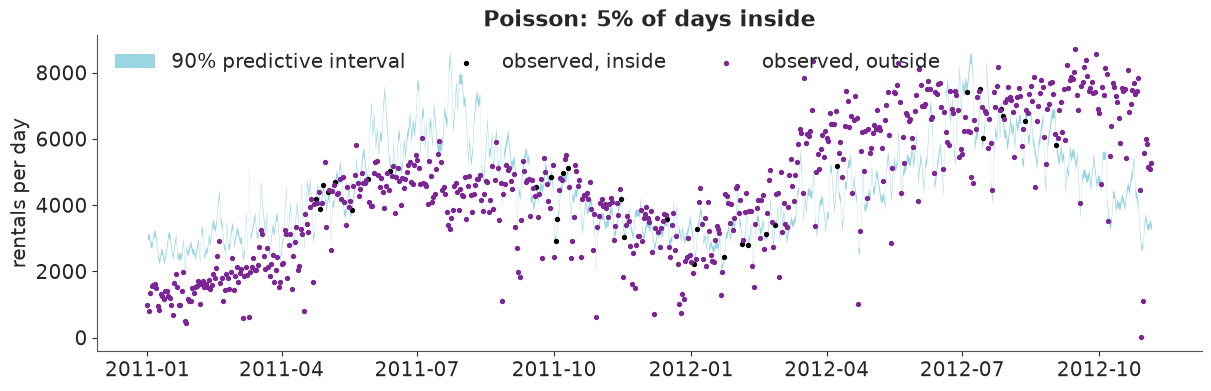

In [9]:
def interval(pp, prob):
    """Central predictive interval per day from predictive draws with chain and draw dimensions."""
    q = pp.quantile([(1 - prob) / 2, (1 + prob) / 2], dim=("chain", "draw"))
    return q.isel(quantile=0).values, q.isel(quantile=1).values


def coverage(pp, y, prob=0.9):
    lo, hi = interval(pp, prob)
    return float(np.mean((y >= lo) & (y <= hi)))


def plot_band(dates, pp, y, ax, title):
    lo, hi = interval(pp, 0.9)
    inside = (y >= lo) & (y <= hi)
    ax.fill_between(dates, lo, hi, color="C0", alpha=0.5, lw=0, label="90% predictive interval")
    ax.scatter(dates[inside], y[inside], s=8, color="k", label="observed, inside")
    ax.scatter(dates[~inside], y[~inside], s=8, color="C3", label="observed, outside")
    ax.set(ylabel="rentals per day", title=f"{title}: {inside.mean():.0%} of days inside")
    ax.legend(ncols=3, loc="upper left")


fig, ax = plt.subplots(figsize=(12, 3.8))
plot_band(train.dteday.values, poisson_idata.posterior_predictive["cnt"], train.cnt.values, ax, "Poisson")

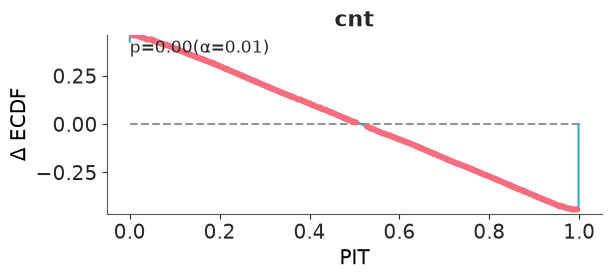

In [10]:
az.plot_ppc_pit(poisson_idata);

In [11]:
def dispersion(idata, y, n_params):
    """Pearson statistic / degrees of freedom: about 1 if the variance really equals the mean."""
    mu_hat = idata.posterior_predictive["cnt"].mean(("chain", "draw")).values
    return float(np.sum((y - mu_hat) ** 2 / mu_hat) / (len(y) - n_params))


poisson_cov = coverage(poisson_idata.posterior_predictive["cnt"], train.cnt.values)
poisson_disp = dispersion(poisson_idata, train.cnt.values, n_params=4)
print(f"coverage of the 90% interval: {poisson_cov:.1%}")
print(f"Pearson dispersion statistic: {poisson_disp:.0f}")

coverage of the 90% interval: 4.7%
Pearson dispersion statistic: 494


In [12]:
assert h.check("task1", coverage90=poisson_cov)

- PASS `coverage90` = 0.04741 is consistent with the reference solution.

**The sampler is fine. The model is not.** `r_hat` of 1.00, thousands of effective draws, no
divergences - and a posterior standard deviation of 0.0006 on every coefficient: the model
claims to know the temperature effect to three decimal places.

Now the predictive checks. The 90% predictive band is a thin ribbon and only **5%** of days
fall inside it, where 90% should. The PIT check says the same thing. For each day, the PIT
value is the share of predictive draws below the observed count; if the predictive
distributions were right these values would be uniform and the Δ-ECDF curve would hug zero.
Instead it runs in a straight line from about +0.45 to -0.45 (ArviZ highlights the points
that break uniformity - here all of them - and prints the p-value of a uniformity test:
0.00). Almost half of all days sit in the extreme lower tail of their own predictive
distribution and almost half in the extreme upper tail.

Why: a Poisson distribution has one parameter, so fixing the mean fixes the spread. With a
mean of 4,500 the standard deviation is √4500 ≈ 67 and a 90% interval is about ±110
rentals. Real days differ from the model's expectation by *thousands*. The Pearson
statistic $\sum (y-\mu)^2/\mu \,/\, (n-p)$ would be about 1 if variance equalled mean; here
it is **494**. (The band plot also shows that the *mean* is poor - the model knows nothing
about growth - and that inflates the statistic. But no set of predictors gets it anywhere
near 1: keep an eye on the dispersion parameter as the mean model improves.)

A marginal density overlay (`az.plot_ppc_dist`) is a weak check here: most of the spread of
daily counts comes from the seasons, which the Poisson model reproduces through its mean.
What the brief needs is the **conditional** distribution - given tomorrow's weather, how
wide? - and that is what coverage and PIT test. (`az.plot_ppc_rootogram` is designed for
this question too, but for small counts; with counts in the thousands it takes minutes and
shows nothing.)

## Task 2 · Fix what Task 1 revealed

Your verdict should have been damning, and "the sampler is fine" is no defence.

**Deliver**
1. The diagnosis in one sentence: **which assumption** of the Task 1 model do the data
   violate, and by roughly what factor? (A number, please.)
2. A repaired model that changes *only* what the diagnosis demands - same predictors, same
   priors for the coefficients. Explain what its new parameter means in words the
   operations team would understand.
3. The same checks as in Task 1, now passed (or not?).
4. Put the posterior standard deviations of the coefficients from both models side by
   side. What happened, and what would it have cost someone who believed the first model?

### Solution

**Diagnosis:** the Poisson assumption *variance = mean* fails by a factor of about 500
(overdispersion). Rentals are not independent events at a fixed rate: one rainy hour, a
festival or a Metro delay moves thousands of trips together.

**Repair:** the negative binomial keeps the mean $\mu$ and adds one parameter:
$\text{Var}(y) = \mu + \mu^2/\alpha$. For counts in the thousands the first term is
negligible, so the standard deviation is $\mu/\sqrt{\alpha}$: demand scatters around its
expectation by a constant *percentage*. That percentage, $cv = 1/\sqrt{\alpha}$, is something the
operations team can relate to, so we put the prior on it directly - `HalfNormal(0.5)`: day-
to-day scatter of tens of percent is plausible, several hundred percent is not - and derive
$\alpha$ from it.

In [13]:
with pm.Model(coords=coords) as negbin_model:
    intercept = pm.Normal("intercept", np.log(4000), 1)
    beta = pm.Normal("beta", 0, 0.5, dims="predictor")
    cv = pm.HalfNormal("cv", 0.5)  # day-to-day coefficient of variation beyond Poisson noise
    alpha = pm.Deterministic("alpha", cv**-2)
    mu = pm.math.exp(intercept + pm.math.dot(Z.values, beta))
    pm.NegativeBinomial("cnt", mu=mu, alpha=alpha, observed=train.cnt.values, dims="day")

negbin_idata = fit(negbin_model)
az.summary(negbin_idata, round_to=3)

NUTS[nutpie]: [intercept, beta, cv]


Sampling: [cnt]


divergences: 0   max r_hat: 1.002   min ess_bulk: 4890


,mean,sd,eti89_lb,eti89_ub,ess_bulk,ess_tail,r_hat,mcse_mean,mcse_sd
intercept,8.356,0.014,8.333,8.379,6710.342,3518.893,1.000,0.000,0.000
beta[temp_c],0.357,0.016,0.331,0.381,5579.699,2928.226,1.002,0.000,0.000
beta[hum_pct],-0.127,0.016,-0.152,-0.101,5753.962,3553.410,1.001,0.000,0.000
beta[wind_kmh],-0.086,0.015,-0.110,-0.063,4890.181,3374.378,1.000,0.000,0.000
cv,0.376,0.010,0.361,0.392,5963.780,3564.517,1.001,0.000,0.000
alpha,7.089,0.373,6.503,7.688,5963.780,3564.517,1.001,0.005,0.005


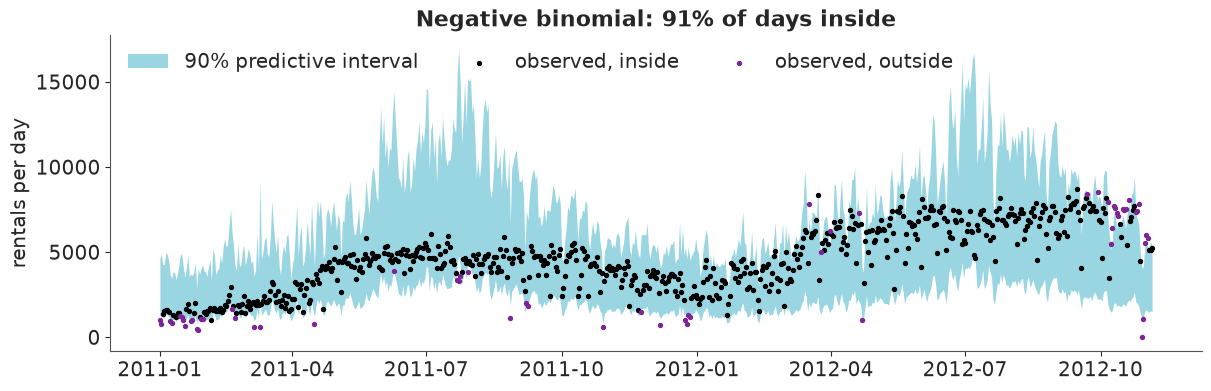

In [14]:
fig, ax = plt.subplots(figsize=(12, 3.8))
plot_band(train.dteday.values, negbin_idata.posterior_predictive["cnt"], train.cnt.values, ax, "Negative binomial")

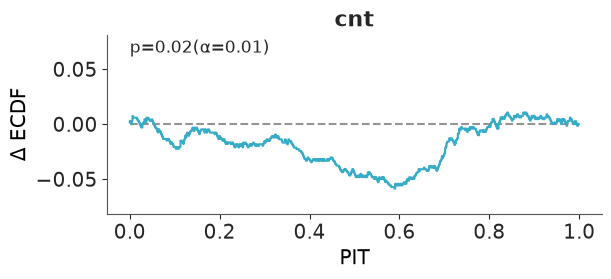

In [15]:
az.plot_ppc_pit(negbin_idata);

In [16]:
negbin_cov = coverage(negbin_idata.posterior_predictive["cnt"], train.cnt.values)
print(f"coverage of the 90% interval: {negbin_cov:.1%}")

sd = pd.DataFrame({
    "Poisson sd": az.summary(poisson_idata, var_names=["intercept", "beta"], round_to="none")["sd"],
    "NegBin sd": az.summary(negbin_idata, var_names=["intercept", "beta"], round_to="none")["sd"],
})
sd["ratio"] = sd["NegBin sd"] / sd["Poisson sd"]
sd.round(4)

coverage of the 90% interval: 91.1%


,Poisson sd,NegBin sd,ratio
intercept,0.0006,0.0145,23.8307
beta[temp_c],0.0006,0.0160,26.1570
beta[hum_pct],0.0006,0.0160,26.3387
beta[wind_kmh],0.0006,0.0151,23.4213


In [17]:
assert h.check(
    "task2",
    dispersion=poisson_disp,
    coverage90=negbin_cov,
    alpha=negbin_idata.posterior["alpha"].mean(),
)

- PASS `dispersion` = 494.4 is consistent with the reference solution.
- PASS `coverage90` = 0.9111 is consistent with the reference solution.
- PASS `alpha` = 7.089 is consistent with the reference solution.

- **Coverage: 91%**, and the PIT curve now stays within 0.06 of zero instead of ±0.45 (mind
  the axis). The uniformity test gives p = 0.02: no longer a disaster, not yet a clean bill
  of health. `cv` is 0.38: knowing temperature, humidity and wind still leaves demand
  uncertain by ±38% (one standard deviation).
- **Honest is not the same as useful.** Look at the band: on a summer day it runs from
  3,000 to 15,000 rentals. Nobody can plan with that. And the misses are not scattered at
  random: they bunch below the band in early 2011 and above it in autumn 2012. Calibration
  on average is the *minimum* requirement; sharpness has to come from a better model for
  the mean, which is the business of the next two tasks.
- **The coefficients' standard deviations grew by a factor of 23 to 26** - about
  √494 ≈ 22, which is what quasi-likelihood theory predicts for this much overdispersion. The
  Poisson model treated each of three million rentals as an independent piece of evidence;
  in truth there are 675 noisy days. Anyone who believed it would have declared every
  conceivable predictor "significant" and would have planned capacity with a margin of
  ±110 rentals. The estimates themselves moved too (temperature from 0.29 to 0.36):
  the Poisson fit is dominated by the busiest days.

## Task 3 · Too hot to cycle

A straight line on the log scale says every extra degree multiplies demand by the same
factor, for ever. Washington summers disagree.

**Deliver**
1. Evidence from the Task 2 model that the linear temperature effect is wrong (a residual
   plot will do).
2. A model in which temperature enters through a **smooth function** instead. Everything
   else stays as in Task 2.
3. A plot of the estimated temperature effect as a *multiplier on expected demand*, with a
   credible band, across the observed temperature range.
4. Two numbers with uncertainty: the temperature at which demand peaks, and how much lower
   (in %) expected demand is at 35 °C than at the peak.

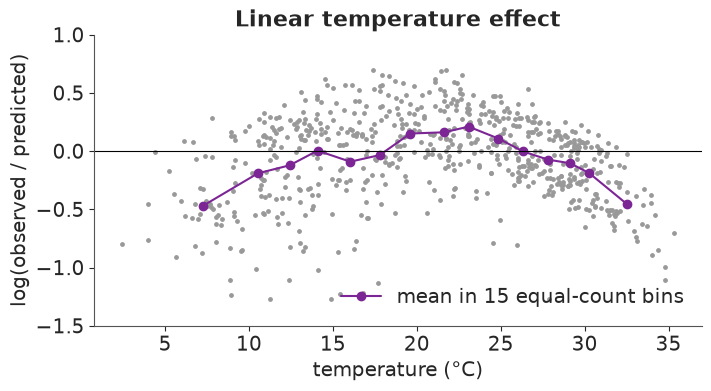

In [18]:
def log_residual(idata, y):
    return np.log(y) - np.log(idata.posterior_predictive["cnt"].mean(("chain", "draw")).values)


def plot_residual_vs_temp(idata, df, ax, title):
    res = pd.DataFrame({"temp_c": df.temp_c.values, "res": log_residual(idata, df.cnt.values)})
    binned = res.groupby(pd.qcut(res.temp_c, 15), observed=True).mean()
    ax.scatter(res.temp_c, res.res, s=6, color="0.6")
    ax.plot(binned.temp_c, binned.res, "o-", color="C3", label="mean in 15 equal-count bins")
    ax.axhline(0, color="k", lw=0.8)
    ax.set(xlabel="temperature (°C)", ylabel="log(observed / predicted)", title=title, ylim=(-1.5, 1))
    ax.legend()


fig, ax = plt.subplots(figsize=(7, 3.8))
plot_residual_vs_temp(negbin_idata, train, ax, "Linear temperature effect")

An inverted U. Around 20-25 °C the model predicts too little (binned residuals of +0.15 to
+0.2 on the log scale); at both ends far too much: about -0.45 for the coldest and for the
hottest bin, which means observed demand is only e^-0.45 ≈ 64% of the prediction. A straight line
cannot rise steeply, flatten and come down again.

**The fix: a regression spline.** `patsy` turns the temperature column into six smooth
basis functions (a natural cubic spline with knots at quantiles of the training data). The
model stays a GLM - six coefficients instead of one - and the curve is
$f(\text{temp}) = \sum_k w_k B_k(\text{temp})$. Two details matter later: the basis is
*centred*, so the intercept keeps its meaning as the log of typical demand; and we keep the
`design_info`, so that new temperatures are expanded with the *same* knots.

From here on one function builds every model, with all inputs registered as `pm.Data` and the
likelihood given `shape=mu.shape`, because we are going to forecast with it.

In [19]:
from patsy import build_design_matrices, dmatrix

# natural cubic regression spline, 6 basis functions, knots at quantiles of the training temperatures;
# "center" removes the constant so the spline does not compete with the intercept
TEMP_SPLINE = dmatrix("cr(temp_c, df=6, constraints='center') - 1", train)


def spline_basis(df):
    """Evaluate the SAME basis (same knots, same centring) for new temperatures."""
    return np.asarray(build_design_matrices([TEMP_SPLINE.design_info], df)[0])


def features(df):
    z = standardise(df)
    return {
        "B": spline_basis(df),
        "hum": z.hum_pct.values,
        "wind": z.wind_kmh.values,
        "weekday_idx": df.weekday.values,
        "weather_idx": df.weathersit.values - 1,
        "holiday": df.holiday.values.astype(float),
        "year2012": df.yr.values - 0.5,
        "t": df.t.values - 1.0,  # years, centred on 1 January 2012
    }


def demand_model(df, calendar=False, trend=None):
    """Negative-binomial demand model. All inputs are pm.Data so that we can forecast later."""
    f = features(df)
    coords = {"knot": np.arange(f["B"].shape[1]), "weekday": WEEKDAYS, "weather": WEATHER, "day": df.dteday.values}
    with pm.Model(coords=coords) as model:
        X = {k: pm.Data(k, v, dims=("day", "knot") if k == "B" else "day") for k, v in f.items()}

        intercept = pm.Normal("intercept", np.log(4000), 1)
        w_temp = pm.Normal("w_temp", 0, 1, dims="knot")
        b_hum = pm.Normal("b_hum", 0, 0.5)
        b_wind = pm.Normal("b_wind", 0, 0.5)
        eta = intercept + pm.math.dot(X["B"], w_temp) + b_hum * X["hum"] + b_wind * X["wind"]

        if calendar:
            weekday_eff = pm.ZeroSumNormal("weekday_eff", 0.3, dims="weekday")
            weather_eff = pm.ZeroSumNormal("weather_eff", 0.5, dims="weather")
            b_holiday = pm.Normal("b_holiday", 0, 0.5)
            eta = eta + weekday_eff[X["weekday_idx"]] + weather_eff[X["weather_idx"]] + b_holiday * X["holiday"]
        if trend is not None:
            growth = pm.Normal("growth", 0, 1)  # change in log demand per year
            eta = eta + growth * (X["year2012"] if trend == "step" else X["t"])

        cv = pm.HalfNormal("cv", 0.5)
        alpha = pm.Deterministic("alpha", cv**-2)
        mu = pm.math.exp(eta)
        pm.NegativeBinomial("cnt", mu=mu, alpha=alpha, observed=df.cnt.values, dims="day", shape=mu.shape)
    return model


spline_model = demand_model(train)
spline_idata = fit(spline_model)
az.summary(spline_idata, var_names=["~alpha"], round_to=3)

NUTS[nutpie]: [intercept, w_temp, b_hum, b_wind, cv]


Sampling: [cnt]


divergences: 0   max r_hat: 1.006   min ess_bulk: 755


,mean,sd,eti89_lb,eti89_ub,ess_bulk,ess_tail,r_hat,mcse_mean,mcse_sd
intercept,8.337,0.013,8.317,8.357,6528.831,3022.096,1.003,0.000,0.000
w_temp[0],0.223,0.083,0.090,0.352,754.525,1383.914,1.006,0.003,0.002
w_temp[1],0.271,0.041,0.204,0.338,1328.949,1904.051,1.003,0.001,0.001
w_temp[2],0.819,0.065,0.712,0.923,930.632,1653.224,1.005,0.002,0.001
w_temp[3],0.914,0.057,0.823,1.005,906.405,1497.019,1.005,0.002,0.001
w_temp[4],1.188,0.081,1.057,1.317,856.600,1389.687,1.006,0.003,0.001
w_temp[5],0.004,0.104,-0.162,0.170,5059.266,2917.481,1.000,0.001,0.002
b_hum,-0.179,0.014,-0.202,-0.156,5419.356,3469.810,1.000,0.000,0.000
b_wind,-0.107,0.013,-0.129,-0.086,5964.008,2890.250,1.002,0.000,0.000
cv,0.324,0.009,0.310,0.338,6815.385,3115.146,1.002,0.000,0.000


training days hotter than 33 °C: 15
demand peaks at 26.4 °C, 94% interval [24.6 28.2]
at 35 °C demand is 36% below the peak, 94% interval [23. 48.]


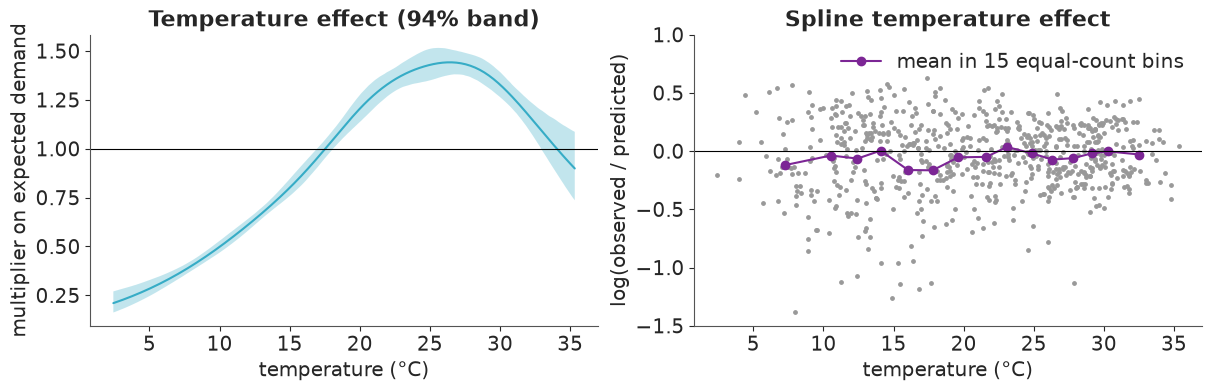

In [20]:
temp_grid = pd.DataFrame({"temp_c": np.linspace(train.temp_c.min(), train.temp_c.max(), 200)})
B_grid = spline_basis(temp_grid)


def temperature_curves(idata):
    """Posterior draws of the spline f(temp) on the grid: array (draws, grid)."""
    w = az.extract(idata, var_names="w_temp").transpose("sample", "knot").values
    return w @ B_grid.T


f_temp = temperature_curves(spline_idata)
peak_temp = temp_grid.temp_c.values[f_temp.argmax(axis=1)]
i35 = np.abs(temp_grid.temp_c.values - 35).argmin()
drop35 = 100 * (1 - np.exp(f_temp[:, i35] - f_temp.max(axis=1)))

fig, axes = plt.subplots(1, 2, figsize=(12, 3.8))
lo, hi = np.quantile(np.exp(f_temp), [0.03, 0.97], axis=0)
axes[0].fill_between(temp_grid.temp_c, lo, hi, alpha=0.3)
axes[0].plot(temp_grid.temp_c, np.exp(f_temp).mean(axis=0))
axes[0].axhline(1, color="k", lw=0.8)
axes[0].set(xlabel="temperature (°C)", ylabel="multiplier on expected demand", title="Temperature effect (94% band)")
plot_residual_vs_temp(spline_idata, train, axes[1], "Spline temperature effect")

print(f"training days hotter than 33 °C: {(train.temp_c > 33).sum()}")
print(f"demand peaks at {peak_temp.mean():.1f} °C, 94% interval {np.quantile(peak_temp, [0.03, 0.97]).round(1)}")
print(f"at 35 °C demand is {drop35.mean():.0f}% below the peak, 94% interval {np.quantile(drop35, [0.03, 0.97]).round(0)}")

In [21]:
assert h.check("task3", peak_temp_c=peak_temp.mean(), drop_at_35_pct=drop35.mean())

- PASS `peak_temp_c` = 26.41 is consistent with the reference solution.
- PASS `drop_at_35_pct` = 36.25 is consistent with the reference solution.

The binned residuals are flat now, and the curve is what a cyclist would draw. Relative to an
average day, the coldest days (2-3 °C) have about a fifth of the demand; demand peaks at
**26 °C** (94% interval 24.6 to 28.2) at about 1.45 times average, and then falls: at 35 °C it
is **36% below the peak**. That last number is uncertain (23% to 48%) because only 15
training days are hotter than 33 °C - the band fans out exactly where the data run out, as
it should.

The spline weights mix a little more slowly than the other parameters (neighbouring basis
functions overlap, so their coefficients are correlated), but `r_hat` stays below 1.01 and
every ESS is above 700. `cv` fell from 0.38 to 0.32: a better mean leaves less to explain as
noise.

## Task 4 · Calendar, weather situation, growth - and a scoreboard

The operations team knows that demand depends on the **day of the week**, on **public
holidays**, on the **weather situation** (rain is worse than humidity alone suggests), and
that the system **grew** between 2011 and 2012. Add all four to the Task 3 model.

**Deliver**
1. A model in which the categorical effects have **no arbitrary reference level**: every
   weekday and every weather situation is treated symmetrically by the prior, and the
   intercept keeps its meaning. Clean diagnostics. The file also offers `workingday` -
   explain why you should not simply add it as well.
2. The effects in units the team can use: by what percentage does a wet day change demand
   relative to a clear one? How much did demand grow from 2011 to 2012? Which weekday is
   busiest? Do not forget the uncertainty.
3. A PSIS-LOO comparison of all four models so far (`az.compare`, `az.plot_compare`) and
   your reading of it: which steps mattered, judged by `elpd_diff` against `dse`? Read the
   warnings - you will come back to them in Task 5.

### Solution

**Coding.** With dummy variables one weekday vanishes into the intercept and the prior
treats it differently from the other six (it has no coefficient, hence no prior
uncertainty of its own). `pm.ZeroSumNormal` gives every level an effect and constrains
them to sum to zero: effects are deviations from the average day, the intercept stays the
average day, and no level is special. We index the effect vector with the integer codes:
`weekday_eff[weekday_idx]`.

**Why not `workingday` as well?** It is an exact function of the others:
`workingday = not weekend and not holiday`. Adding it gives the model two ways to say the
same thing; only the priors would hold the posterior together. Weekday effects plus a
holiday effect carry strictly more information.

**Growth.** The file offers `yr`, so the obvious first choice is a step: every 2012 day is
some percentage above the comparable 2011 day. We centre it (-0.5 / +0.5). Prior scales:
weekday effects of a few tens of percent at most (`sigma=0.3`), weather situations
possibly a halving (`sigma=0.5`), growth `Normal(0, 1)` per year because a young system
can plausibly double.

In [22]:
step_model = demand_model(train, calendar=True, trend="step")
step_idata = fit(step_model)
az.summary(step_idata, var_names=["~alpha", "~w_temp"], round_to=3)

NUTS[nutpie]: [intercept, w_temp, b_hum, b_wind, weekday_eff, weather_eff, b_holiday, growth, cv]


Sampling: [cnt]


divergences: 0   max r_hat: 1.007   min ess_bulk: 739


,mean,sd,eti89_lb,eti89_ub,ess_bulk,ess_tail,r_hat,mcse_mean,mcse_sd
intercept,8.142,0.021,8.109,8.175,1158.675,1558.045,1.002,0.001,0.000
b_hum,-0.072,0.013,-0.093,-0.051,2301.483,2690.799,1.002,0.000,0.000
b_wind,-0.088,0.010,-0.104,-0.073,5018.654,3197.073,1.001,0.000,0.000
b_holiday,-0.098,0.060,-0.195,-0.004,5888.627,3118.086,1.000,0.001,0.001
growth,0.424,0.019,0.394,0.453,6312.089,3704.807,1.000,0.000,0.000
weekday_eff[Sun],-0.054,0.022,-0.090,-0.018,6116.909,3097.037,1.000,0.000,0.000
weekday_eff[Mon],-0.017,0.023,-0.054,0.020,5676.370,3333.472,1.001,0.000,0.000
weekday_eff[Tue],-0.001,0.022,-0.036,0.035,6841.480,3132.760,1.002,0.000,0.000
weekday_eff[Wed],-0.011,0.023,-0.047,0.026,6812.623,2990.153,1.004,0.000,0.000
weekday_eff[Thu],0.017,0.023,-0.018,0.053,6863.603,3262.187,1.000,0.000,0.000


wet day vs clear day          -46.4%   94% interval [-52.5, -39.9]
misty day vs clear day         -9.9%   94% interval [-14.0, -5.5]
public holiday                 -9.2%   94% interval [-19.0, +1.7]
2012 vs 2011                  +52.8%   94% interval [+47.4, +58.2]
humidity +1 sd                 -6.9%   94% interval [-9.3, -4.6]
wind +1 sd                     -8.4%   94% interval [-10.1, -6.8]


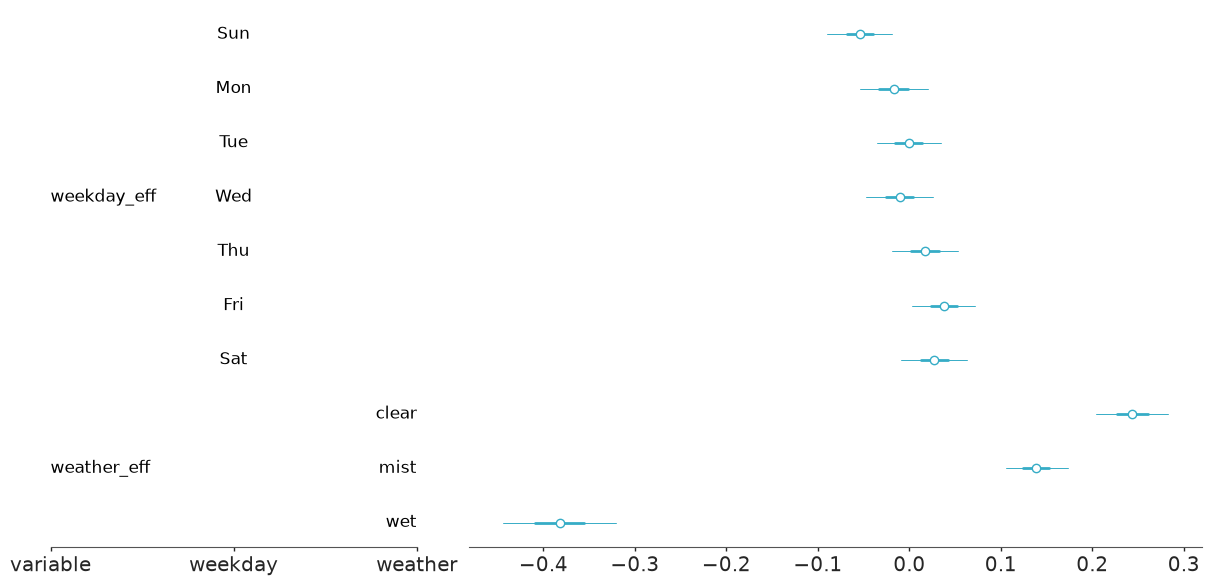

In [23]:
def pct(x):
    return 100 * (np.exp(x) - 1)


def report(name, draws):
    lo, hi = np.quantile(draws, [0.03, 0.97])
    print(f"{name:<28} {draws.mean():+6.1f}%   94% interval [{lo:+.1f}, {hi:+.1f}]")


post = az.extract(step_idata)
wet_vs_clear = pct(post["weather_eff"].sel(weather="wet") - post["weather_eff"].sel(weather="clear")).values
mist_vs_clear = pct(post["weather_eff"].sel(weather="mist") - post["weather_eff"].sel(weather="clear")).values
growth_pct = pct(post["growth"]).values
report("wet day vs clear day", wet_vs_clear)
report("misty day vs clear day", mist_vs_clear)
report("public holiday", pct(post["b_holiday"]).values)
report("2012 vs 2011", growth_pct)
report("humidity +1 sd", pct(post["b_hum"]).values)
report("wind +1 sd", pct(post["b_wind"]).values)

az.plot_forest(step_idata, var_names=["weekday_eff", "weather_eff"], combined=True);

In [24]:
train.groupby("weekday_name", observed=True)[["casual", "registered", "cnt"]].mean().round(0).T

weekday_name,Sun,Mon,Tue,Wed,Thu,Fri,Sat
casual,1385.0,693.0,570.0,571.0,607.0,765.0,1512.0
registered,2892.0,3627.0,3921.0,3964.0,4078.0,3914.0,3070.0
cnt,4277.0,4320.0,4490.0,4535.0,4685.0,4679.0,4582.0


In [25]:
assert h.check("task4", wet_vs_clear_pct=wet_vs_clear.mean(), growth_pct=growth_pct.mean())

- PASS `wet_vs_clear_pct` = -46.41 is consistent with the reference solution.
- PASS `growth_pct` = 52.84 is consistent with the reference solution.

- A **wet day costs 46%** of demand relative to a clear day with the same temperature,
  humidity and wind (94% interval -52% to -40%); mist costs 10%.
- **2012 is 53% above 2011** (47% to 58%) at equal weather and calendar.
- Public holidays: about -9%, but the interval reaches zero - there are only 18 holidays
  in the training data.
- Once the weather situation is in the model the humidity coefficient shrinks from -0.18 to
  -0.07: the two carry much of the same information.
- **Weekday effects are tiny**: Sunday -5%, Friday +4%, everything else within a
  couple of percent of average. The table above shows why that is not the whole story:
  casual riders more than double at weekends while registered riders (commuters) drop by
  about a quarter, and in the total the two patterns almost cancel. A lead for "Going
  further".

`cv` is down to 0.24. Diagnostics are clean (no divergences, `r_hat` below 1.01). In the
table the smallest ESS (around 1,100) belongs to the intercept and the weather effects,
which trade off against each other because the levels are so unbalanced (64% of training
days are "clear", only 20 are "wet"); the slowest parameters overall are still the spline
weights, at about 740.

In [26]:
ladder = {
    "1 Poisson, linear weather": poisson_idata,
    "2 NegBin, linear weather": negbin_idata,
    "3 NegBin, temperature spline": spline_idata,
    "4 + calendar, weather, growth": step_idata,
}
loos = {name: az.loo(idata, pointwise=True) for name, idata in ladder.items()}  # compute once, reuse
az.compare(loos, round_to=1)

/Users/redam94/Coding/coding_challenge/.venv/lib/python3.12/site-packages/arviz_stats/loo/loo_helper.py:1170: UserWarning: Estimated shape parameter of Pareto distribution is greater than 0.70 for one or more samples. You should consider using a more robust model, this is because importance sampling is less likely to work well if the marginal posterior and LOO posterior are very different. This is more likely to happen with a non-robust model and highly influential observations.
  warnings.warn(


/Users/redam94/Coding/coding_challenge/.venv/lib/python3.12/site-packages/arviz_stats/loo/loo_helper.py:1170: UserWarning: Estimated shape parameter of Pareto distribution is greater than 0.70 for one or more samples. You should consider using a more robust model, this is because importance sampling is less likely to work well if the marginal posterior and LOO posterior are very different. This is more likely to happen with a non-robust model and highly influential observations.
  warnings.warn(


,rank,elpd_diff,dse,p_worse,diag_diff,diag_elpd,p,elpd,se,weight
"4 + calendar, weather, growth",0,0.0,0.0,NaN,,1 k̂ > 0.70,30.4,-5603.8,63.7,1.0
"3 NegBin, temperature spline",1,-204.6,34.1,1.0,,,12.6,-5808.4,36.8,0.0
"2 NegBin, linear weather",2,-305.3,43.4,1.0,,,6.7,-5909.1,27.7,0.0
"1 Poisson, linear weather",3,-169988.9,8724.7,1.0,,133 k̂ > 0.70,1938.9,-175592.7,8755.8,0.0


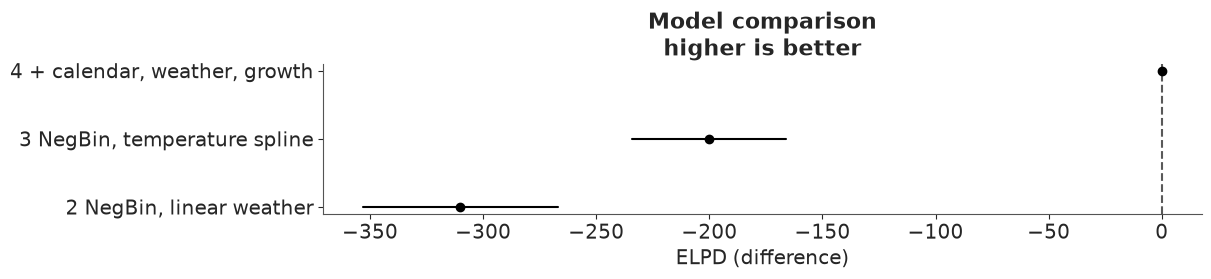

In [27]:
az.plot_compare(az.compare({k: v for k, v in loos.items() if "Poisson" not in k}));

In [28]:
# dse is always relative to the top row; for the spline-versus-line question compare just those two
az.compare({k: loos[k] for k in ["2 NegBin, linear weather", "3 NegBin, temperature spline"]}, round_to=1)[["elpd_diff", "dse", "p"]]

,elpd_diff,dse,p
"3 NegBin, temperature spline",0.0,0.0,12.6
"2 NegBin, linear weather",-100.7,16.1,6.7


How to read the scoreboard:

- **Poisson: 170,000 elpd behind.** Not a typo. The log score punishes confident wrong
  predictions without mercy, and a model that calls most days a one-in-a-billion event is
  as confidently wrong as it gets. Its `p_loo` of about 1,900 for a model with 4 parameters
  and 133 bad Pareto-$k$ values say the same: the number itself is unreliable, the verdict is
  not.
- **Spline vs straight line: about 100 elpd**, six times the `dse` of that pair (16, second
  table). Remember that `dse` in the big table is always relative to the top row.
- **Calendar, weather situation and growth: another 205 elpd**, six times its `dse` of 34.
  No surprise after Task 0, where the gap between the years was visible from across the room.
- The best model has `p_loo` of 30 although it has only about 20 free parameters, and
  the table flags **one observation with $\hat k > 0.7$**. Something in the data has more
  influence than any single day should. That is Task 5.

## Task 5 · The days the model cannot believe

LOO is not only a scoreboard. It computes, for every single day, how well the model predicts
that day when it has *not* seen it - and how much the posterior leans on it.

**Deliver**
1. For your best model so far: the pointwise elpd and the Pareto-$k$ value of every
   training day, plotted against the date, and a table of the six most surprising days.
2. For the worst of them: what happened? (You have the date and the internet.) Is it the
   kind of day the brief asks you to forecast? Look at the other five as well - is any of
   them a *data* problem rather than a demand problem?
3. A decision on how to handle what you found, with a justification an auditor would
   accept, and a refit. What changed in the dispersion and in the width of the predictive
   intervals - and why does one day out of 675 have that much leverage?

,cnt,weather,temp_c,hum_pct,wind_kmh,predicted,elpd,pareto_k
dteday,,,,,,,,
2012-10-29,22,wet,18.04,88.00,24.00,2176.0,-67.36,1.23
2011-01-27,431,clear,8.00,68.75,7.63,1731.0,-17.17,0.41
2011-03-10,623,wet,15.95,0.00,17.55,2157.0,-16.27,0.36
2011-08-27,1115,mist,27.88,85.00,25.17,3215.0,-13.99,0.21
2011-03-06,605,mist,15.44,94.83,23.00,1821.0,-13.86,0.15
2012-10-30,1096,mist,13.05,82.55,14.27,3028.0,-13.42,0.22


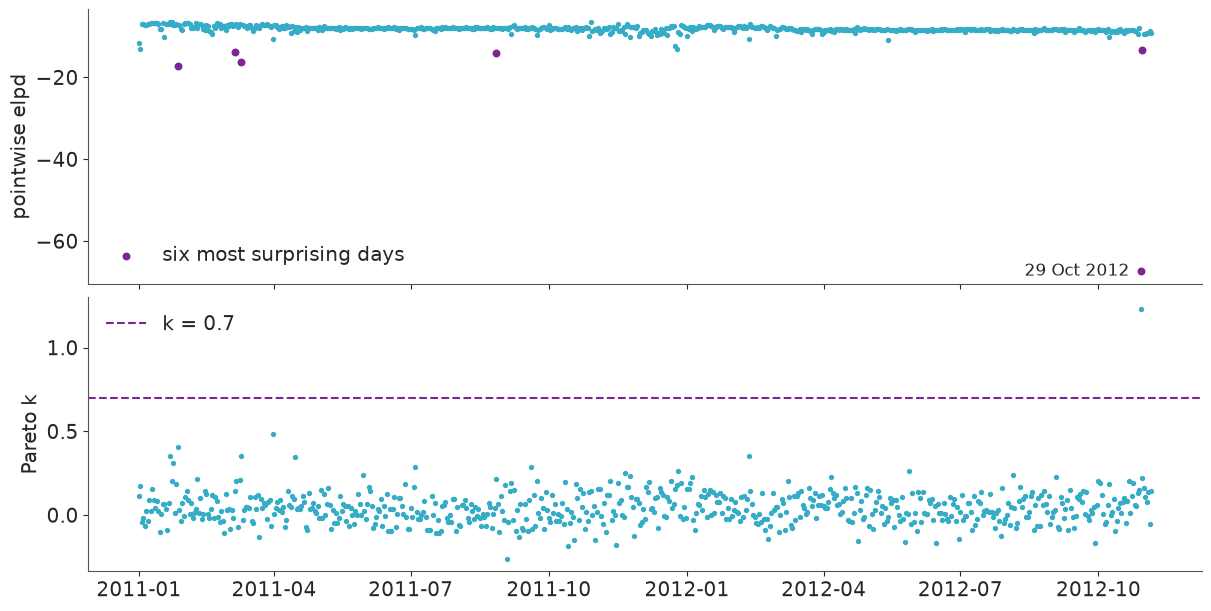

In [29]:
loo4 = loos["4 + calendar, weather, growth"]
pointwise = train[["dteday", "cnt", "weather", "temp_c", "hum_pct", "wind_kmh"]].assign(
    predicted=step_idata.posterior_predictive["cnt"].mean(("chain", "draw")).values.round(),
    elpd=loo4.elpd_i.values,
    pareto_k=loo4.pareto_k.values,
)
surprising = pointwise.nsmallest(6, "elpd").set_index("dteday")

fig, axes = plt.subplots(2, 1, figsize=(12, 6), sharex=True)
axes[0].scatter(pointwise.dteday, pointwise.elpd, s=8)
axes[0].set(ylabel="pointwise elpd")
axes[1].scatter(pointwise.dteday, pointwise.pareto_k, s=8)
axes[1].axhline(0.7, color="C3", ls="--", label="k = 0.7")
axes[1].set(ylabel="Pareto k")
axes[1].legend()
axes[0].scatter(surprising.index, surprising.elpd, s=22, color="C3", label="six most surprising days")
axes[0].annotate(f"{surprising.index[0]:%d %b %Y}", (surprising.index[0], surprising.elpd.iloc[0]),
                 xytext=(-8, 0), textcoords="offset points", ha="right", va="center")
axes[0].legend(loc="lower left")

surprising.round(2)

In [30]:
worst = pointwise.loc[pointwise.elpd.idxmin()]
assert h.check("task5", cnt_worst_day=worst.cnt, k_worst_day=worst.pareto_k)

- PASS `cnt_worst_day` = 22 is consistent with the reference solution.
- PASS `k_worst_day` = 1.228 is consistent with the reference solution.

A typical day has a pointwise elpd of about -8 or -9. Then there is **29 October 2012: 22
rentals, elpd -67, Pareto-$k$ 1.2** - the only day beyond the 0.7 threshold. That is the
day Hurricane Sandy reached Washington: the federal government and public transport shut
down, and with 22 rentals in 24 hours the bike-share system was evidently closed too. The
model sees "18 °C, wet, windy" and expects about 2,200 rentals. The next day (1,096 rentals
where 3,000 were expected) is in the list as well.

The others are instructive in different ways:

- **27 January 2011** (431 rentals, "clear", 8 °C): the day after a heavy snowstorm. The sky
  was clear; the snow on the ground is not in the data.
- **27 August 2011**: Hurricane Irene. **6 March 2011**: 95% humidity and strong wind, but
  coded as "mist". For both, the three-level weather code understates how bad the day was.
- **10 March 2011**: humidity of **0.00%** on a wet day. That is not weather, that is a
  failed sensor - a *data* anomaly, which the model turned into a wrong prediction because it
  believed the number.

**What to do.** These are three different kinds of problem and deserve different answers:

1. *Sandy (29-30 October 2012):* remove. On those days we did not observe demand, we
   observed a closed system. The brief is about staffing a system that operates; nobody
   needs a rebalancing plan for a hurricane shutdown. We state the condition - "forecasts
   assume normal operation" - rather than hide the deletion.
2. *The humidity reading:* repair (interpolate between the neighbouring days). The day
   itself is fine.
3. *Snow, Irene, the wet "misty" day:* **keep**. Bad days that the weather code describes
   poorly will happen again, and the predictive distribution should be wide enough to admit it.
   Deleting every day the model dislikes is how one ends up with beautifully narrow, wrong
   intervals.

In [31]:
SANDY = pd.to_datetime(["2012-10-29", "2012-10-30"])

train_clean = train[~train.dteday.isin(SANDY)].copy()
train_clean["hum_pct"] = train_clean.hum_pct.where(train_clean.hum_pct > 0).interpolate()  # sensor failure
print(f"humidity on 10 March 2011 after the repair: {train_clean.loc[train_clean.dteday == '2011-03-10', 'hum_pct'].item():.1f}%")

step_clean_model = demand_model(train_clean, calendar=True, trend="step")
step_clean_idata = fit(step_clean_model)
loo_step_clean = az.loo(step_clean_idata, pointwise=True)


def mean_width(idata, prob=0.9):
    lo, hi = interval(idata.posterior_predictive["cnt"], prob)
    return (hi - lo).mean()


for name, idata, loo in [("with Sandy", step_idata, loo4), ("without", step_clean_idata, loo_step_clean)]:
    print(
        f"{name:<11} cv = {float(idata.posterior['cv'].mean()):.3f}   alpha = {float(idata.posterior['alpha'].mean()):.1f}   "
        f"mean width of 90% interval = {mean_width(idata):.0f}   days with k > 0.7: {int((loo.pareto_k > 0.7).sum())}"
    )

humidity on 10 March 2011 after the repair: 71.2%


NUTS[nutpie]: [intercept, w_temp, b_hum, b_wind, weekday_eff, weather_eff, b_holiday, growth, cv]


Sampling: [cnt]


divergences: 0   max r_hat: 1.006   min ess_bulk: 783


with Sandy  cv = 0.236   alpha = 18.0   mean width of 90% interval = 3543   days with k > 0.7: 1
without     cv = 0.211   alpha = 22.4   mean width of 90% interval = 3185   days with k > 0.7: 0


Two days out of 675, and `cv` drops from 0.236 to 0.211 ($\alpha$ from 18 to 22); the average
90% interval narrows by 10% (3,543 to 3,185 rentals); no Pareto-$k$ above 0.7 remains.

Why so much leverage? The model has **one** dispersion parameter for all days. Under a
negative binomial expecting a couple of thousand rentals, a count of 22 is astronomically
unlikely unless $\alpha$ is small - so the likelihood buys a little plausibility for that
one day by making *every* day noisier. That is exactly what a large Pareto-$k$ means: the
posterior with and without this observation are different posteriors.

One caution: do not compare the elpd of this fit with the scoreboard of Task 4. The data
are different (a day worth -67 is gone), so the totals are not comparable.

## Task 6 · Open the hold-out

Time to find out whether "90%" means 90%. Forecast the 56 hold-out days with the model from
Task 5, using the weather that actually occurred (a perfect weather forecast - the best
case).

**Deliver**
1. Forecasts produced **without refitting**: swap the inputs of the fitted model and sample
   the posterior predictive.
2. A plot of the 50% and 90% predictive intervals against the actual counts, plus the
   empirical coverage of both intervals and the mean error (forecast median minus actual).
3. If the forecasts are biased: find out **why** - not by tuning against the hold-out, but
   by asking what your growth term assumes about November 2012, and checking that assumption
   on the *training* data. Fix the model, compare old and new with LOO, and forecast again.
4. A list of the hold-out days that still fall outside the 90% interval. What do they have in
   common? Could the training data have warned you? (Task 5 again.) Which direction is the
   error, and how much does that direction hurt the operations team?

In [32]:
def forecast(model, idata, new):
    """Posterior predictive draws of cnt for the rows of `new`, without refitting."""
    with model:
        pm.set_data(features(new), coords={"day": new.dteday.values})
        pred = pm.sample_posterior_predictive(idata, predictions=True, random_seed=RANDOM_SEED)
    return pred.predictions["cnt"]


def score(pp, y):
    median = pp.median(("chain", "draw")).values
    return {
        "coverage50": coverage(pp, y, 0.5),
        "coverage90": coverage(pp, y, 0.9),
        "mean error": float(np.mean(median - y)),
        "mean abs error": float(np.mean(np.abs(median - y))),
    }


def plot_forecast(pp, df, ax, title):
    y, dates = df.cnt.values, df.dteday.values
    lo90, hi90 = interval(pp, 0.9)
    lo50, hi50 = interval(pp, 0.5)
    outside = (y < lo90) | (y > hi90)
    ax.fill_between(dates, lo90, hi90, color="C0", alpha=0.25, lw=0, label="90%")
    ax.fill_between(dates, lo50, hi50, color="C0", alpha=0.5, lw=0, label="50%")
    ax.scatter(dates[~outside], y[~outside], s=14, color="k", zorder=3)
    ax.scatter(dates[outside], y[outside], s=14, color="C3", zorder=3, label="outside 90%")
    ax.set(ylabel="rentals per day", title=title, ylim=(0, 10500))
    ax.legend(ncols=3, loc="upper right")


pp_step = forecast(step_clean_model, step_clean_idata, test)
scores = {"step growth": score(pp_step, test.cnt.values)}
pd.DataFrame(scores).T.round(2)

Sampling: [cnt]


,coverage50,coverage90,mean error,mean abs error
step growth,0.25,0.66,-650.96,1151.63


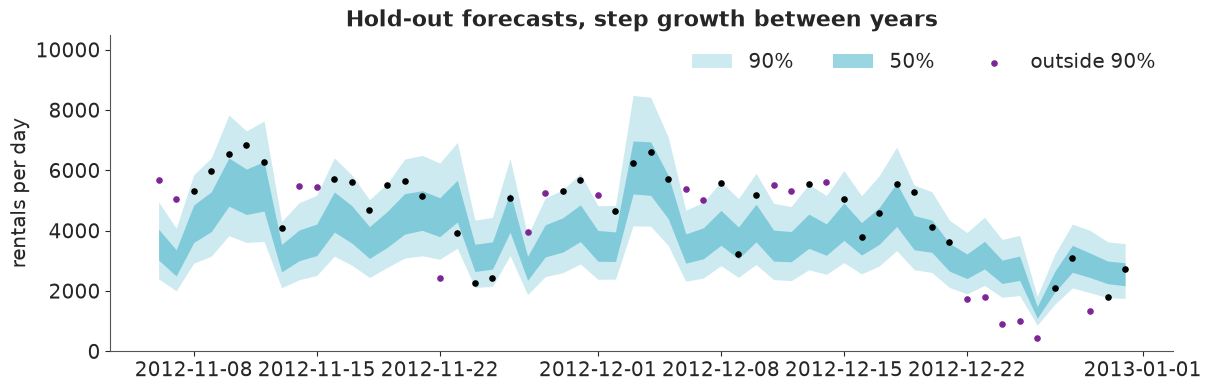

In [33]:
fig, ax = plt.subplots(figsize=(12, 3.8))
plot_forecast(pp_step, test, ax, "Hold-out forecasts, step growth between years")

Not good. Only **66%** of the hold-out days are inside the 90% interval and 25% inside the 50%
interval. Worse, the errors are one-sided: the median forecast is on average **650 rentals
too low**, and before Christmas every miss but one is *above* the band. Under-forecasting
is the expensive direction for the operations team.

The training coverage gave no hint of this. Nor would LOO: leaving out one day at a time
tests *interpolation* - the neighbours of the missing day are still there. Forecasting
is *extrapolation* in time, and only a hold-out at the end of the series tests that.

Why is the model biased? The growth term says "2012 is 53% above 2011" - one level per
year. If the system actually grew steadily, that is too high for the start of each year and
too low for the end. We can check that on the training data alone:

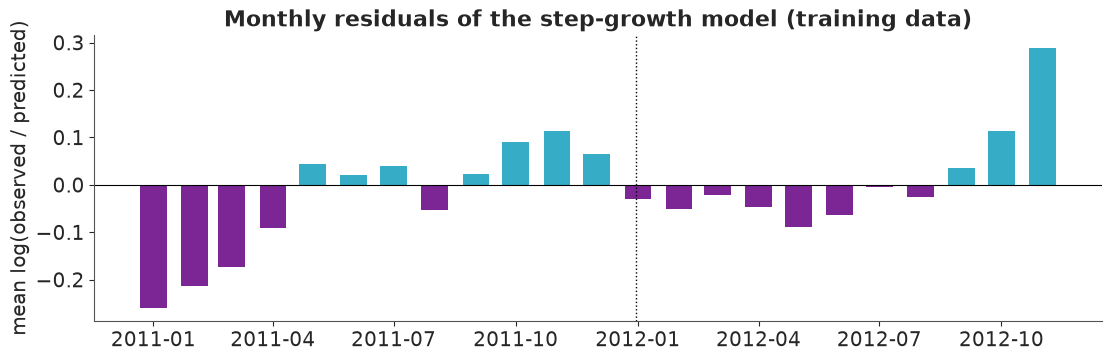

In [34]:
monthly = pd.DataFrame({"month": train_clean.dteday.dt.to_period("M").dt.to_timestamp(),
                        "res": log_residual(step_clean_idata, train_clean.cnt.values)}).groupby("month").res.mean()

fig, ax = plt.subplots(figsize=(11, 3.5))
ax.bar(monthly.index, monthly.values, width=20, color=np.where(monthly.values > 0, "C0", "C3"))
ax.axhline(0, color="k", lw=0.8)
ax.axvline(pd.Timestamp("2011-12-31"), color="k", ls=":", lw=1)
ax.set(ylabel="mean log(observed / predicted)", title="Monthly residuals of the step-growth model (training data)");

A saw-tooth. Within each year the residuals climb from negative to positive: -0.26 in January
2011, +0.11 by November 2011, back below zero in January 2012, and up to +0.11 in October
2012 (the last bar, +0.29, is only the first five days of November). The step model
describes the *average* of 2012; the hold-out is the *end* of 2012.

The fix is a trend in continuous time: `growth * t` with `t` in years. It costs no extra
parameter.

In [35]:
final_model = demand_model(train_clean, calendar=True, trend="linear")
final_idata = fit(final_model)
az.summary(final_idata, var_names=["intercept", "growth", "b_holiday", "b_hum", "b_wind", "cv"], round_to=3)

NUTS[nutpie]: [intercept, w_temp, b_hum, b_wind, weekday_eff, weather_eff, b_holiday, growth, cv]


Sampling: [cnt]


divergences: 0   max r_hat: 1.005   min ess_bulk: 875


,mean,sd,eti89_lb,eti89_ub,ess_bulk,ess_tail,r_hat,mcse_mean,mcse_sd
intercept,8.170,0.017,8.143,8.198,882.212,1386.668,1.005,0.001,0.000
growth,0.463,0.015,0.438,0.487,4903.188,3110.141,1.000,0.000,0.000
b_holiday,-0.117,0.048,-0.193,-0.038,5560.712,3092.677,1.001,0.001,0.001
b_hum,-0.093,0.011,-0.111,-0.076,2032.121,2841.664,1.000,0.000,0.000
b_wind,-0.064,0.008,-0.077,-0.051,3803.992,2777.460,1.001,0.000,0.000
cv,0.192,0.005,0.184,0.201,5775.052,3223.565,1.001,0.000,0.000


In [36]:
loo_final = az.loo(final_idata, pointwise=True)
az.compare({"step growth": loo_step_clean, "linear growth": loo_final}, round_to=1)

,rank,elpd_diff,dse,p_worse,diag_diff,diag_elpd,p,elpd,se,weight
linear growth,0,0.0,0.0,NaN,,,24.4,-5447.8,33.5,0.8
step growth,1,-62.3,17.9,1.0,,,23.1,-5510.1,26.9,0.2


Sampling: [cnt]


,coverage50,coverage90,mean error,mean abs error
step growth,0.25,0.66,-650.96,1151.63
linear growth,0.50,0.79,402.76,914.81


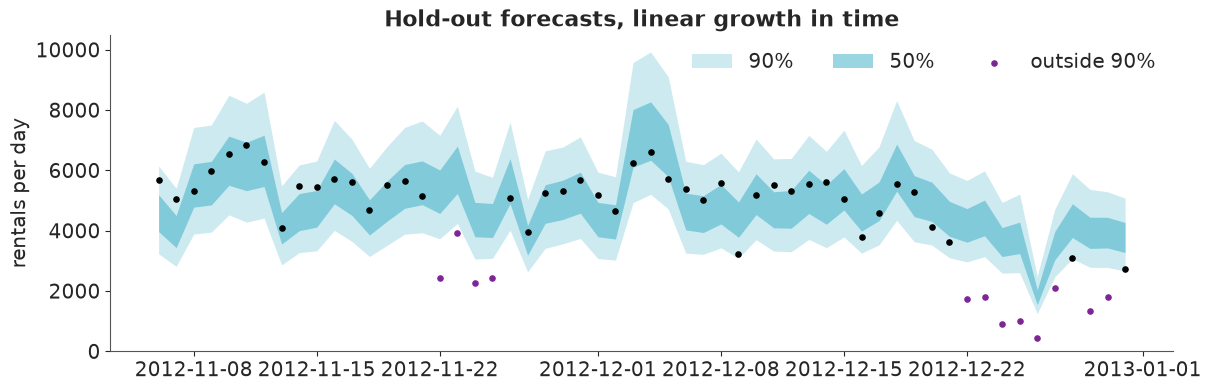

In [37]:
pp_final = forecast(final_model, final_idata, test)
scores["linear growth"] = score(pp_final, test.cnt.values)

fig, ax = plt.subplots(figsize=(12, 3.8))
plot_forecast(pp_final, test, ax, "Hold-out forecasts, linear growth in time")
pd.DataFrame(scores).T.round(2)

In [38]:
lo90, hi90 = interval(pp_final, 0.9)
missed = test.assign(lo90=lo90, hi90=hi90)[(test.cnt.values < lo90) | (test.cnt.values > hi90)]
missed.set_index("dteday")[["weekday_name", "holiday", "weather", "cnt", "lo90", "hi90"]].round(0)

,weekday_name,holiday,weather,cnt,lo90,hi90
dteday,,,,,,
2012-11-22,Thu,1,clear,2425,3732.0,7163.0
2012-11-23,Fri,0,clear,3910,4241.0,8128.0
2012-11-24,Sat,0,clear,2277,3060.0,5973.0
2012-11-25,Sun,0,clear,2424,3083.0,5769.0
2012-12-22,Sat,0,clear,1749,2964.0,5664.0
2012-12-23,Sun,0,clear,1787,3139.0,5984.0
2012-12-24,Mon,0,mist,920,2593.0,4937.0
2012-12-25,Tue,1,mist,1013,2608.0,5211.0
2012-12-26,Wed,0,wet,441,1251.0,2486.0


In [39]:
print("most surprising TRAINING days under the final model:")
train_clean.assign(elpd=loo_final.elpd_i.values).nsmallest(6, "elpd").set_index("dteday")[["weekday_name", "weather", "cnt", "elpd"]].round(1)

most surprising TRAINING days under the final model:


,weekday_name,weather,cnt,elpd
dteday,,,,
2011-12-25,Sun,clear,754,-21.1
2011-01-27,Thu,clear,431,-20.4
2011-12-24,Sat,clear,1011,-19.5
2011-08-27,Sat,mist,1115,-19.1
2011-03-06,Sun,mist,605,-15.2
2011-12-27,Tue,mist,1162,-14.4


In [40]:
holiday_season = (test.dteday.between("2012-11-22", "2012-11-25") | (test.dteday >= "2012-12-22")).values
ordinary = score(pp_final.isel(day=~holiday_season), test.cnt.values[~holiday_season])
print(f"{(~holiday_season).sum()} hold-out days outside Thanksgiving weekend and the Christmas period:")
print({k: round(v, 2) for k, v in ordinary.items()})

growth_per_year = pct(final_idata.posterior["growth"]).values.ravel()
print(f"growth: {growth_per_year.mean():.0f}% per year, 94% interval {np.quantile(growth_per_year, [0.03, 0.97]).round(0)}")
assert h.check(
    "task6",
    coverage90_first=scores["step growth"]["coverage90"],
    coverage90_final=scores["linear growth"]["coverage90"],
    growth_pct_per_year=growth_per_year.mean(),
)

42 hold-out days outside Thanksgiving weekend and the Christmas period:
{'coverage50': 0.67, 'coverage90': 1.0, 'mean error': -150.29, 'mean abs error': 532.45}
growth: 59% per year, 94% interval [54. 64.]


- PASS `coverage90_first` = 0.6607 is consistent with the reference solution.
- PASS `coverage90_final` = 0.7857 is consistent with the reference solution.
- PASS `growth_pct_per_year` = 58.87 is consistent with the reference solution.

- **LOO** prefers the linear trend by 62 elpd (3.5 times its `dse`), with the same number of
  parameters, and `cv` falls again, to 0.19 - still more than ten times the 1.5% that a
  Poisson model allows at 4,500 rentals a day. Growth is **59% per year** (54% to 64%). Here
  LOO and the hold-out agree - but LOO alone did not tell us that the step model would
  *forecast* badly.
- **Hold-out:** the 50% interval now covers 50% of days. The 90% interval covers
  **79%**, and the bias has changed sign (+400).
- The 12 misses are all **below** the band and they are not random: Thanksgiving Thursday
  to Sunday (22-25 November) and the Christmas period from 22 December. On the other 42
  days the 90% interval covers every single day, the 50% interval two thirds of them, and
  the mean error is -150: on ordinary days the intervals are, if anything, somewhat too
  wide. (One shared `cv` also has to stretch over the festive and storm days in the
  training data.)
- **Could we have known?** Yes. Under the final model the most surprising training days are
  24, 25 and 27 December 2011. The `holiday` flag marks single official holidays (-11%);
  it knows nothing about a city that empties for a week. One Christmas in the training data
  is thin evidence, but it was there, and pointwise LOO showed it. (First item in "Going
  further".)
- **Does it hurt?** These errors are *over*-forecasts: vans and staff planned for riders who
  stayed at home. By the costs in the next task that is the cheap direction - but a team that
  sees the model miss ten days in a row will stop trusting it, so tell them in advance:
  *in holiday weeks, plan below the model.*

## Task 7 · How much capacity?

The team plans three days in the coming weeks and hands you the weather forecast for each.
(None is a public holiday.)

In [41]:
scenarios = pd.DataFrame(
    {
        "date": pd.to_datetime(["2012-11-16", "2012-11-18", "2012-11-20"]),
        "temp_c": [14.0, 8.0, 11.0],
        "hum_pct": [50.0, 70.0, 90.0],
        "wind_kmh": [10.0, 20.0, 15.0],
        "weather": ["clear", "mist", "wet"],
    },
    index=["mild clear Friday", "cold misty Sunday", "wet Tuesday"],
)
COST_LOST_RENTAL = 4.0  # $ per rental the system could not serve (lost fare and goodwill)
COST_IDLE = 0.5  # $ per unit of capacity planned but not used (vans, staff, bikes standing by)
scenarios

,date,temp_c,hum_pct,wind_kmh,weather
mild clear Friday,2012-11-16,14.0,50.0,10.0,clear
cold misty Sunday,2012-11-18,8.0,70.0,20.0,mist
wet Tuesday,2012-11-20,11.0,90.0,15.0,wet


**Deliver**
1. For each scenario the capacity (in rentals per day) that covers demand with probability
   95%, from your final model - and, next to it, the number you would get if you
   (wrongly) used only the uncertainty about the *expected* demand. How big is the gap?
2. Management's 95% is a rule of thumb. With the two costs above, find the capacity that
   **minimises expected cost** for each scenario, numerically from the predictive draws.
   Which quantile of the predictive distribution does it correspond to? What ratio of the
   two costs would make the 95% rule optimal?
3. Three sentences for the operations team: what to plan, how far to trust it, and when
   not to.

In [42]:
new = scenarios.assign(
    dteday=scenarios.date,
    weekday=(scenarios.date.dt.dayofweek + 1) % 7,  # pandas: Monday = 0; the file: Sunday = 0
    weathersit=[WEATHER.index(w) + 1 for w in scenarios.weather],
    holiday=0,
    yr=1,
    t=(scenarios.date - pd.Timestamp("2011-01-01")).dt.days / 365.25,
)
pp_new = forecast(final_model, final_idata, new)
draws = pp_new.stack(sample=("chain", "draw")).transpose("sample", "day").values  # (draws, 3 days)

Sampling: [cnt]


In [43]:
def expected_demand(idata, df):
    """Posterior draws of mu (expected rentals) for the rows of df under the final model: (draws, rows)."""
    p = az.extract(idata)
    f = features(df)
    eta = (
        p["intercept"].values[:, None]
        + p["w_temp"].transpose("sample", "knot").values @ f["B"].T
        + p["b_hum"].values[:, None] * f["hum"]
        + p["b_wind"].values[:, None] * f["wind"]
        + p["weekday_eff"].transpose("sample", "weekday").values[:, f["weekday_idx"]]
        + p["weather_eff"].transpose("sample", "weather").values[:, f["weather_idx"]]
        + p["b_holiday"].values[:, None] * f["holiday"]
        + p["growth"].values[:, None] * f["t"]
    )
    return np.exp(eta)


mu_draws = expected_demand(final_idata, new)
capacity = pd.DataFrame(
    {
        "median forecast": np.median(draws, axis=0),
        "95% of expected demand (wrong)": np.quantile(mu_draws, 0.95, axis=0),
        "capacity95 (predictive)": np.quantile(draws, 0.95, axis=0),
    },
    index=scenarios.index,
)
capacity["safety margin"] = capacity["capacity95 (predictive)"] / capacity["median forecast"] - 1
capacity["P(shortfall) with the wrong number"] = (draws > capacity["95% of expected demand (wrong)"].values).mean(axis=0)
capacity.round({"median forecast": 0, "95% of expected demand (wrong)": 0, "capacity95 (predictive)": 0,
                "safety margin": 2, "P(shortfall) with the wrong number": 2})

,median forecast,95% of expected demand (wrong),capacity95 (predictive),safety margin,P(shortfall) with the wrong number
mild clear Friday,5800.0,6146.0,7862.0,0.36,0.39
cold misty Sunday,2594.0,2813.0,3542.0,0.37,0.35
wet Tuesday,1909.0,2118.0,2613.0,0.37,0.29


newsvendor critical fractile: 0.889


,capacity95 (predictive),optimal capacity,quantile of optimum,expected cost at optimum,expected cost at capacity95
mild clear Friday,7862.05,7330.0,0.89,1042.51,1122.75
cold misty Sunday,3542.05,3290.0,0.89,480.85,517.44
wet Tuesday,2613.05,2420.0,0.89,362.22,391.62


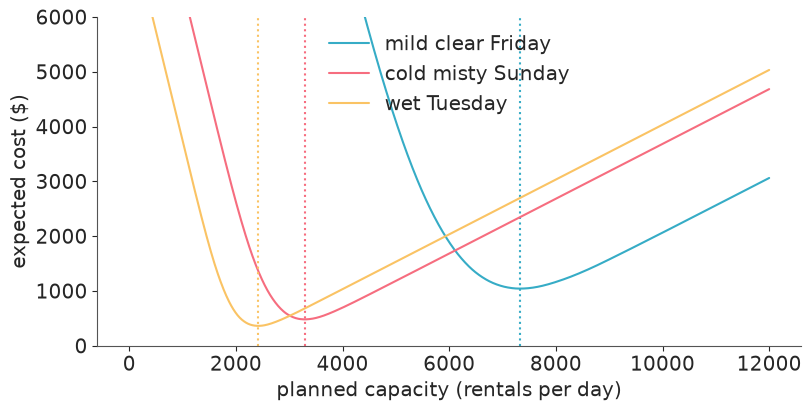

In [44]:
def expected_cost(capacity_grid, demand):
    """Expected cost of each capacity on the grid, averaging over predictive draws of demand."""
    short = np.clip(demand[None, :] - capacity_grid[:, None], 0, None)
    idle = np.clip(capacity_grid[:, None] - demand[None, :], 0, None)
    return (COST_LOST_RENTAL * short + COST_IDLE * idle).mean(axis=1)


grid = np.arange(0, 12001, 10)
fig, ax = plt.subplots(figsize=(8, 4))
for i, name in enumerate(scenarios.index):
    cost = expected_cost(grid, draws[:, i])
    best = grid[cost.argmin()]
    capacity.loc[name, "optimal capacity"] = best
    capacity.loc[name, "quantile of optimum"] = np.mean(draws[:, i] <= best)
    capacity.loc[name, "expected cost at optimum"] = cost.min()
    capacity.loc[name, "expected cost at capacity95"] = np.interp(capacity.loc[name, "capacity95 (predictive)"], grid, cost)
    ax.plot(grid, cost, color=f"C{i}", label=name)
    ax.axvline(best, color=f"C{i}", ls=":")
ax.set(xlabel="planned capacity (rentals per day)", ylabel="expected cost ($)", ylim=(0, 6000))
ax.legend()

critical_fractile = COST_LOST_RENTAL / (COST_LOST_RENTAL + COST_IDLE)
print(f"newsvendor critical fractile: {critical_fractile:.3f}")
capacity[["capacity95 (predictive)", "optimal capacity", "quantile of optimum",
          "expected cost at optimum", "expected cost at capacity95"]].round(2)

In [45]:
assert h.check(
    "task7",
    capacity95_friday=capacity.loc["mild clear Friday", "capacity95 (predictive)"],
    optimal_capacity_friday=capacity.loc["mild clear Friday", "optimal capacity"],
    optimal_quantile=capacity["quantile of optimum"].mean(),
)

- PASS `capacity95_friday` = 7862 is consistent with the reference solution.
- PASS `optimal_capacity_friday` = 7330 is consistent with the reference solution.
- PASS `optimal_quantile` = 0.8896 is consistent with the reference solution.

**Predictive, not posterior.** For the mild Friday the median forecast is 5,800 rentals and
the 95% capacity is **about 7,900** - a safety margin of 36% (and the same 36-37% in the
other scenarios, because negative-binomial scatter is proportional to the mean). The 95%
quantile of the *expected* demand $\mu$ is only 6,150: it measures how well we know the
average of many such Fridays, not how this Friday will turn out. Plan with it and you fall
short on three to four such days in ten, not one in twenty (last column).

**The 95% rule is a cost statement in disguise.** Minimising expected cost over the
predictive draws gives a capacity of about 7,330 for the Friday, which is the 0.89 quantile
in every scenario - the newsvendor result $q^* = c_\text{short} / (c_\text{short} +
c_\text{idle}) = 4 / 4.5$. The 95% rule costs about 8% more in expectation. It would be
optimal if a lost rental cost **19 times** as much as a unit of idle capacity
($0.95 = 19/20$). Maybe it does - empty docks make headlines - but that is for management
to say, and now they can say it in dollars.

**For the operations team:**

1. Plan for the model's 95% quantile - about a third above the central forecast - or for
   the 89% quantile if the two costs above are right; the forecast table gives both for any
   weather forecast you type in.
2. On ordinary days the ranges have held up on eight weeks the model never saw. They assume
   the weather forecast is right, that the system operates normally, and that growth
   continues at the pace of 2011-2012 - the first assumption to re-check every few months,
   because nothing grows at 59% a year for long.
3. Do not trust it around Thanksgiving and between Christmas and New Year, where it
   over-forecasts by a wide margin, and do not expect it to foresee a hurricane.

## Going further

- **Holiday seasons.** The final model over-forecasts Thanksgiving weekend and the week after
  Christmas. Give it a way to learn that from 2011 (one Christmas is not much - what prior
  keeps the estimate honest?) and check whether hold-out coverage improves.
- **Two populations.** `casual` and `registered` riders have opposite weekday patterns and
  different sensitivity to weather. Model them separately (or jointly, with shared growth)
  and add the predictive draws. Does the total forecast get sharper?
- **A Gaussian process instead of a spline.** Replace the temperature spline with
  `pm.gp.HSGP`, and the linear trend with a slowly-varying HSGP in time. Does the
  temperature curve change where data are sparse? What happens to forecasts when the trend
  is a GP that reverts to its mean?
- **The weather forecast is uncertain too.** Tomorrow's temperature is known to within a
  couple of degrees and "wet" is a probability. Propagate that through the capacity
  decision by sampling scenarios. When does it matter?

In [46]:
h.progress()

**C03**: 0/23 hints used, 18/18 checks passed.